# 03 — AI Capital Markets Agent: Pipeline Evaluation

End-to-end evaluation of the multi-agent capital markets pipeline across 8 sector ETFs.  
Covers model accuracy, backtesting, portfolio construction, hypothesis testing, LLM sentiment validation, and runtime profiling.

| Section | Topic |
|---|---|
| Cell 1 | Setup — data, metrics, forecasts, recommendations |
| Cell 2 | ML Model Evaluation — confusion matrices |
| Cell 3 | Backtesting — strategy vs buy-and-hold |
| Cell 4 | Portfolio Evaluation — equal weight vs model weights vs SPY |
| Cell 5 | Hypothesis Validation |
| Cell 6 | LLM Sentiment Accuracy |
| Cell 7 | Agent Pipeline Timing |
| Cell 8 | Summary Dashboard |

## Cell 1 — Setup

In [7]:
import sys
import os
import warnings
import time

warnings.filterwarnings('ignore')

# Make src/ importable from the notebooks/ directory
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score,
)
from matplotlib.patches import Patch

# Pipeline modules
from data_loader import load_data
from metrics import compute_metrics, RISK_FREE_RATE, TRADING_DAYS
from forecasting import build_features, train_model, run_forecasting, FEATURE_COLS

# Global plot style
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlepad': 8})

# ── Load market data ────────────────────────────────────────────────────────
print('Loading market data...')
data_dict = load_data()

# ── Compute financial metrics ───────────────────────────────────────────────
print('\nComputing financial metrics...')
metrics_df = compute_metrics(data_dict)

# ── Run ML forecasting ──────────────────────────────────────────────────────
# run_forecasting trains one Random Forest per ticker and returns
# {ticker: P(positive next-week return)}
print('\nRunning ML forecasting (trains 8 models)...')
forecasts = run_forecasting(data_dict)

# ── Pipeline recommendations (from full LangGraph agent run) ────────────────
RECOMMENDATIONS = {
    'GLD': 'Overweight',
    'SPY': 'Overweight',
    'QQQ': 'Neutral',
    'XLE': 'Neutral',
    'UUP': 'Neutral',
    'XLV': 'Underweight',
    'TLT': 'Underweight',
    'XLF': 'Avoid',
}

# LLM sentiment labels produced by sentiment_agent (GPT-4o-mini)
LLM_SENTIMENTS = {
    'GLD': 'Bullish',
    'SPY': 'Bullish',
    'QQQ': 'Neutral',
    'XLE': 'Neutral',
    'UUP': 'Bearish',
    'XLV': 'Bearish',
    'TLT': 'Bearish',
    'XLF': 'Bearish',
}

TICKERS = sorted(RECOMMENDATIONS.keys())

print(f'\n\u2713 Setup complete. Tickers: {TICKERS}')
print('\nForecast probabilities:')
for t in TICKERS:
    print(f'  {t:<6} {forecasts.get(t, float("nan")):.1%}  ({RECOMMENDATIONS[t]})')

Loading market data...
[data_loader] Loading 8 tickers from e:\Job projects\BMO\project\capital-markets-agent\notebooks\..\src\..\data\raw ...
  -> Loaded SPY: 1105 rows (2022-01-03 to 2026-05-29)
  -> Loaded QQQ: 1105 rows (2022-01-03 to 2026-05-29)
  -> Loaded XLF: 1105 rows (2022-01-03 to 2026-05-29)
  -> Loaded XLE: 1105 rows (2022-01-03 to 2026-05-29)
  -> Loaded XLV: 1105 rows (2022-01-03 to 2026-05-29)
  -> Loaded TLT: 1105 rows (2022-01-03 to 2026-05-29)
  -> Loaded GLD: 1105 rows (2022-01-03 to 2026-05-29)
  -> Loaded UUP: 1105 rows (2022-01-03 to 2026-05-29)
[data_loader] Load complete. 8/8 tickers available.

Computing financial metrics...
[metrics] Computing metrics for 8 tickers (benchmark: SPY, risk-free rate: 5%) ...
  -> SPY ... ann_ret=+12.6%  vol=17.6%  sharpe=0.43  maxDD=-24.5%  beta=1.00
  -> QQQ ... ann_ret=+15.6%  vol=23.2%  sharpe=0.46  maxDD=-34.8%  beta=1.26
  -> XLF ... ann_ret=+8.1%  vol=18.6%  sharpe=0.16  maxDD=-25.8%  beta=0.86
  -> XLE ... ann_ret=+20.8% 

## Cell 2 — ML Model Evaluation: Confusion Matrices

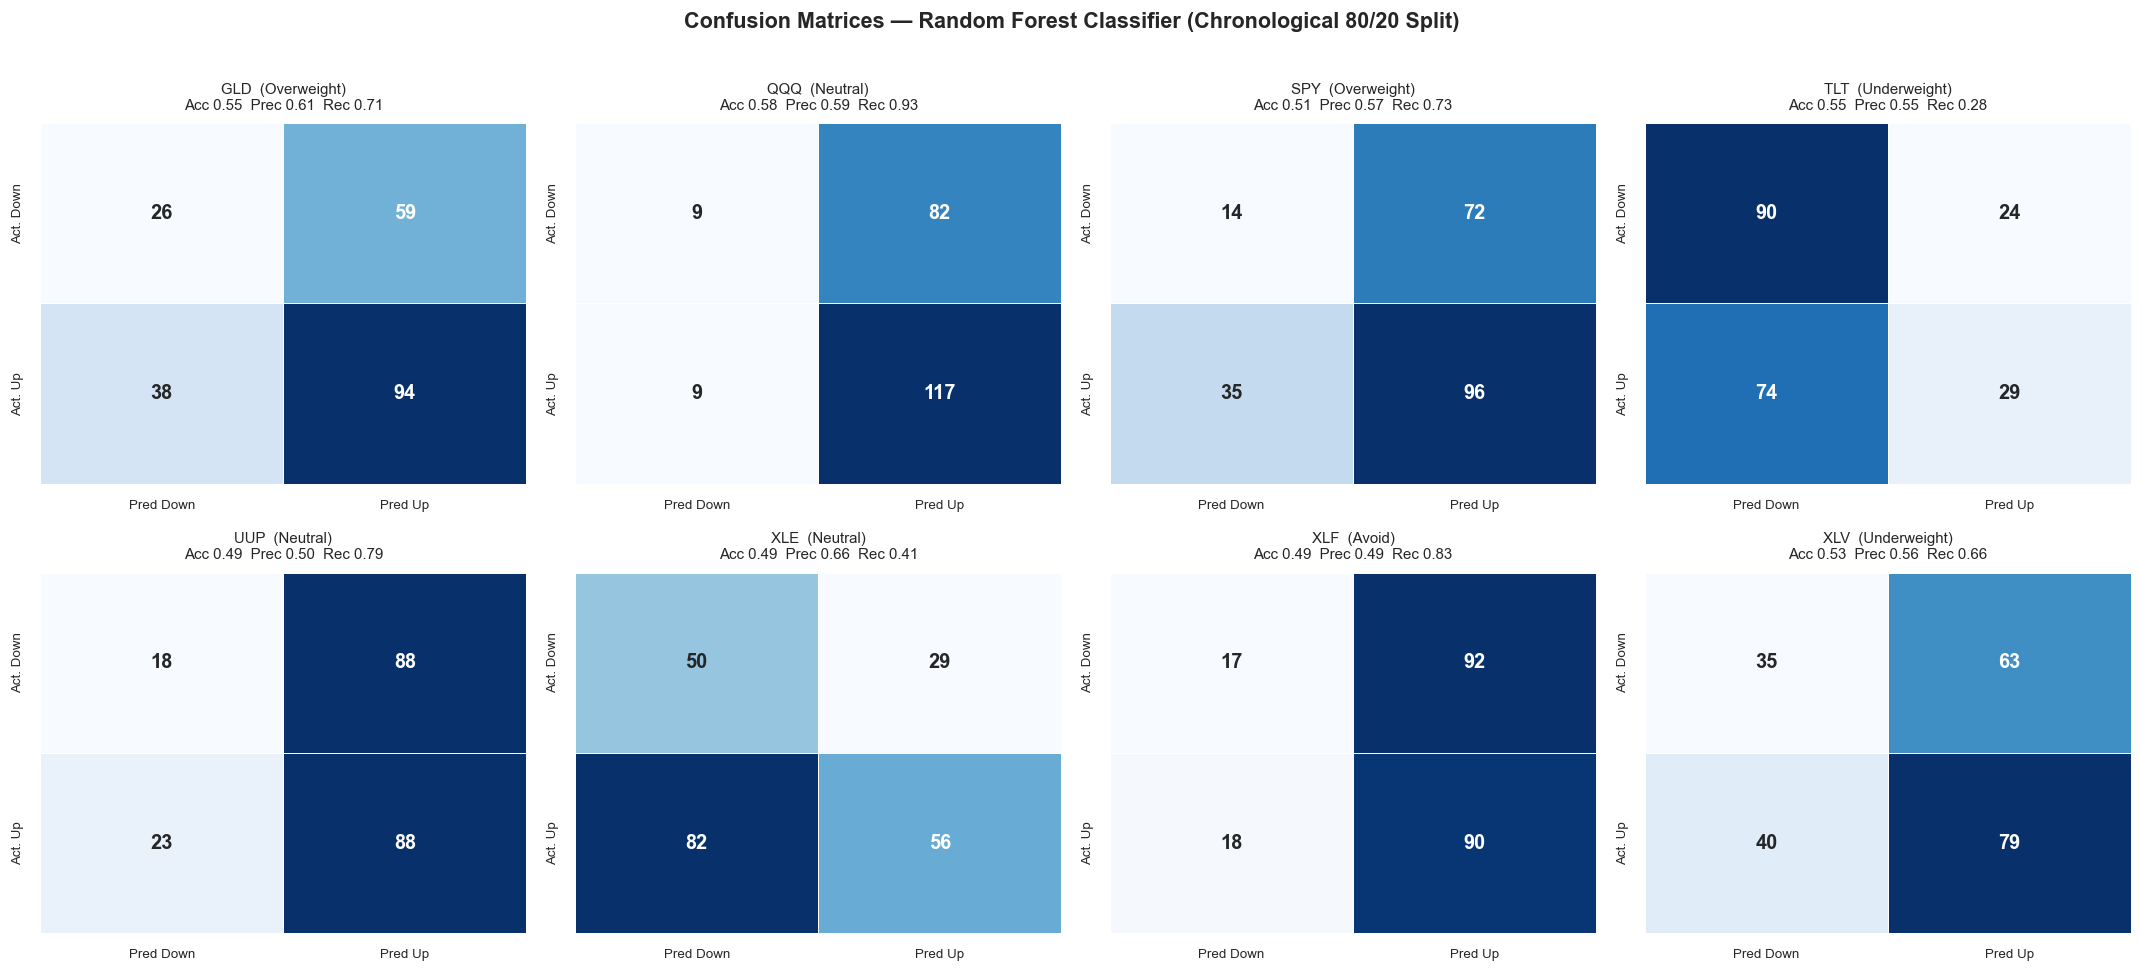


Model Evaluation Summary:


,Recommendation,Accuracy,Precision,Recall,Test Samples
Ticker,,,,,
GLD,Overweight,0.553,0.614,0.712,217
QQQ,Neutral,0.581,0.588,0.929,217
SPY,Overweight,0.507,0.571,0.733,217
TLT,Underweight,0.548,0.547,0.282,217
UUP,Neutral,0.488,0.500,0.793,217
XLE,Neutral,0.488,0.659,0.406,217
XLF,Avoid,0.493,0.495,0.833,217
XLV,Underweight,0.525,0.556,0.664,217


In [8]:
# Train one Random Forest per ticker (same hyperparameters as forecasting.py)
# and display all 8 confusion matrices in a 2x4 grid.

os.makedirs('../data/processed', exist_ok=True)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(
    'Confusion Matrices — Random Forest Classifier (Chronological 80/20 Split)',
    fontsize=13, fontweight='bold', y=1.01
)

# Store trained models and test results for use in later cells
model_results = {}

for idx, ticker in enumerate(TICKERS):
    ax = axes[idx // 4][idx % 4]

    # Feature construction and chronological 80/20 split
    feat = build_features(data_dict[ticker])
    split_idx = int(len(feat) * 0.80)
    train_df = feat.iloc[:split_idx]
    test_df  = feat.iloc[split_idx:]

    X_train = train_df[FEATURE_COLS]
    y_train = train_df['target']
    X_test  = test_df[FEATURE_COLS]
    y_test  = test_df['target']

    # Train with the same config as forecasting.py
    model = RandomForestClassifier(
        n_estimators=200, max_depth=6,
        min_samples_leaf=10, random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    probs  = model.predict_proba(X_test)[:, 1]  # P(class=1 = up)

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred, zero_division=0)

    # Persist for cells 3 and 8
    model_results[ticker] = {
        'model': model, 'test_df': test_df,
        'y_test': y_test, 'y_pred': y_pred, 'probs': probs,
        'accuracy': acc, 'precision': prec, 'recall': rec,
    }

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Pred Down', 'Pred Up'],
        yticklabels=['Act. Down', 'Act. Up'],
        linewidths=0.5, linecolor='white', cbar=False,
        annot_kws={'size': 12, 'weight': 'bold'}
    )
    ax.set_title(
        f'{ticker}  ({RECOMMENDATIONS[ticker]})\n'
        f'Acc {acc:.2f}  Prec {prec:.2f}  Rec {rec:.2f}',
        fontsize=9
    )
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('../data/processed/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
eval_rows = []
for t in TICKERS:
    r = model_results[t]
    eval_rows.append({
        'Ticker': t,
        'Recommendation': RECOMMENDATIONS[t],
        'Accuracy':  round(r['accuracy'],  3),
        'Precision': round(r['precision'], 3),
        'Recall':    round(r['recall'],    3),
        'Test Samples': len(r['y_test']),
    })

eval_table = pd.DataFrame(eval_rows).set_index('Ticker')
print('\nModel Evaluation Summary:')
display(eval_table)

## Cell 3 — Backtesting: Strategy vs Buy-and-Hold

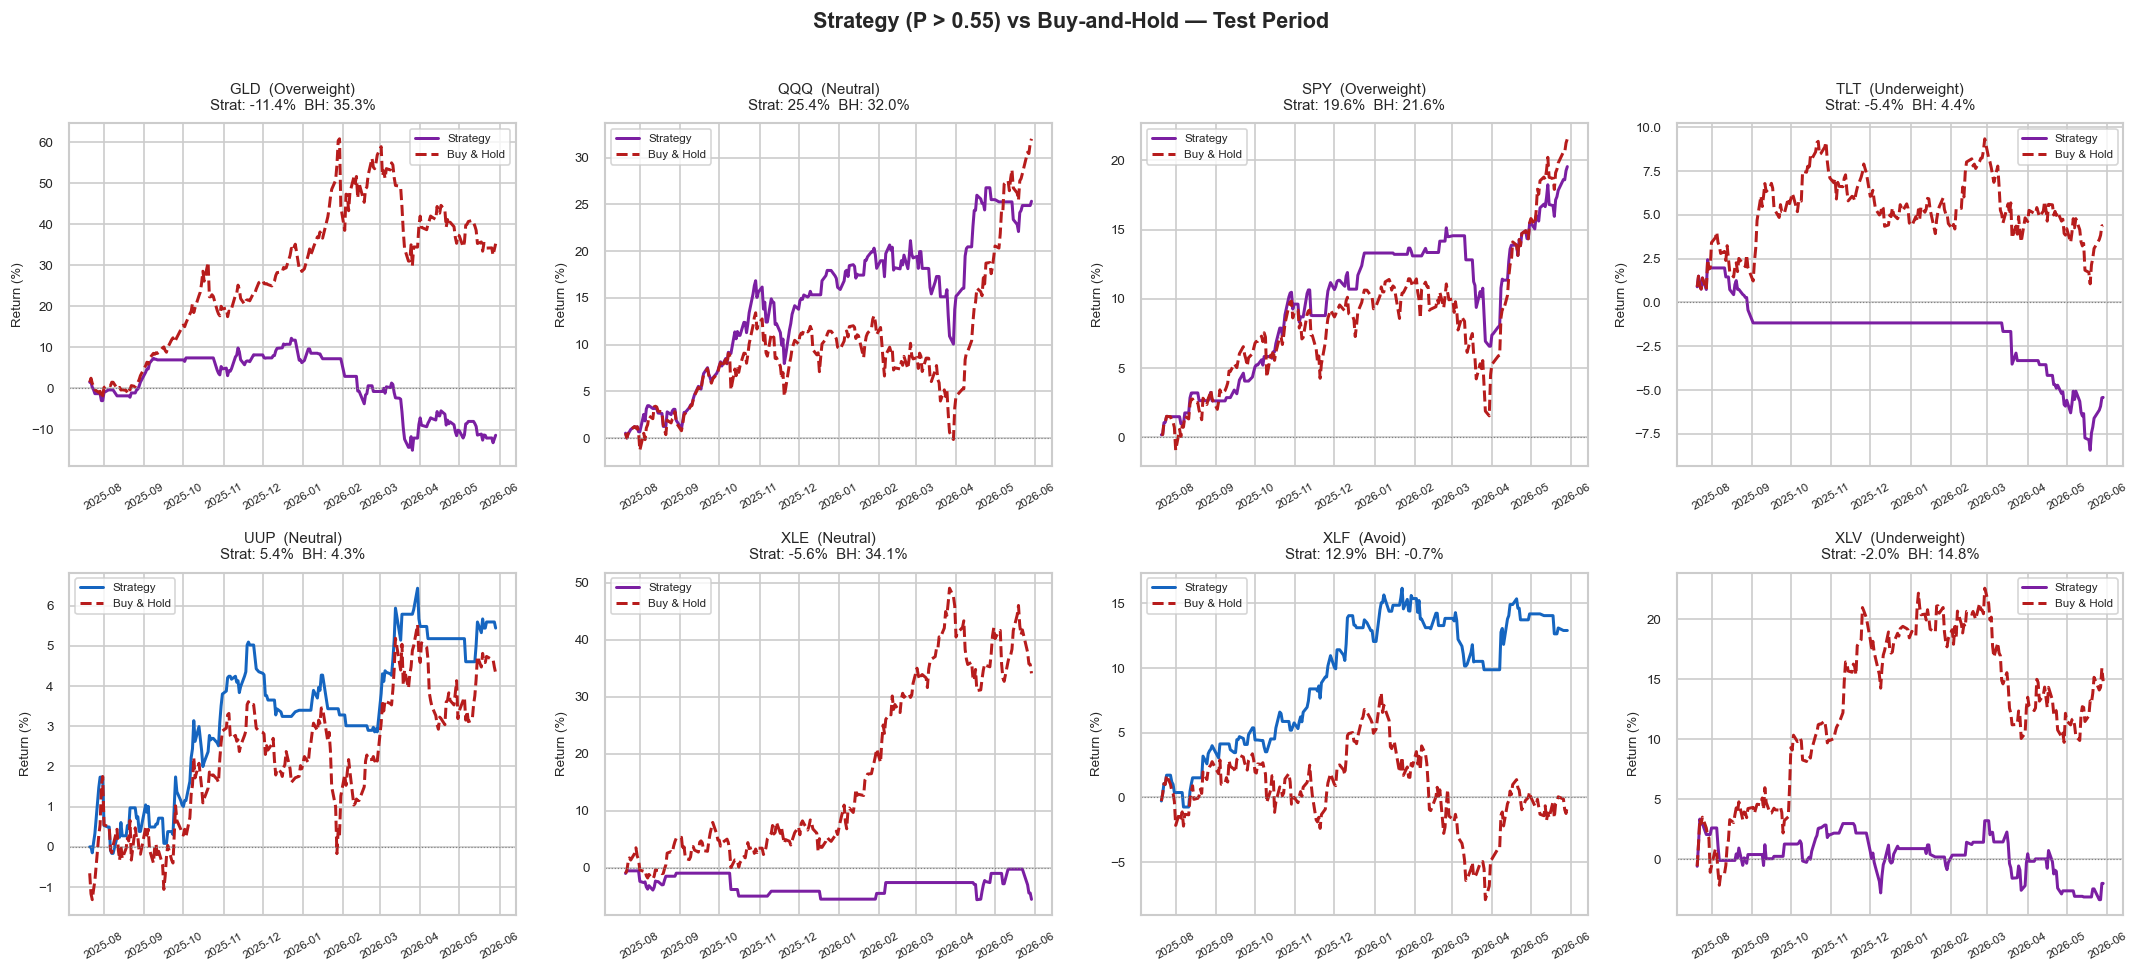


Backtesting Summary (test period only):


,Recommendation,Strategy Return,Buy & Hold Return,Alpha,Beats BH,Days In Market
Ticker,,,,,,
GLD,Overweight,-11.38%,35.26%,-46.63%,✗,134/217
QQQ,Neutral,25.35%,32.03%,-6.68%,✗,172/217
SPY,Overweight,19.56%,21.56%,-2.01%,✗,122/217
TLT,Underweight,-5.42%,4.40%,-9.82%,✗,53/217
UUP,Neutral,5.44%,4.32%,+1.12%,✓,126/217
XLE,Neutral,-5.57%,34.08%,-39.66%,✗,38/217
XLF,Avoid,12.90%,-0.65%,+13.55%,✓,121/217
XLV,Underweight,-1.99%,14.85%,-16.84%,✗,104/217



Strategy outperforms buy-and-hold in 2/8 tickers


In [9]:
# Simulated trading strategy:
#   Buy signal : model P(up) > 0.55  →  capture that day's daily return
#   Hold cash  : model P(up) <= 0.55 →  0% return that day
# Evaluated only on the held-out test period (last 20% of each ticker's history).

BUY_THRESHOLD = 0.55

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(
    f'Strategy (P > {BUY_THRESHOLD}) vs Buy-and-Hold — Test Period',
    fontsize=13, fontweight='bold', y=1.01
)

backtest_results = {}

for idx, ticker in enumerate(TICKERS):
    ax = axes[idx // 4][idx % 4]

    res     = model_results[ticker]
    test_df = res['test_df']
    probs   = res['probs']

    # Daily signal: 1 = in market, 0 = cash
    signal = (probs > BUY_THRESHOLD).astype(int)

    # Align actual daily returns to the test-set dates
    daily_ret = data_dict[ticker]['Close'].pct_change()
    test_ret  = daily_ret.reindex(test_df.index).fillna(0.0)

    strat_ret = pd.Series(signal * test_ret.values, index=test_df.index)
    bh_ret    = test_ret

    cum_strat = (1 + strat_ret).cumprod() - 1
    cum_bh    = (1 + bh_ret).cumprod() - 1

    backtest_results[ticker] = {
        'strategy_total': float(cum_strat.iloc[-1]),
        'bh_total':       float(cum_bh.iloc[-1]),
        'days_in_market': int(signal.sum()),
        'total_days':     int(len(signal)),
    }

    outperforms = cum_strat.iloc[-1] > cum_bh.iloc[-1]
    color_strat = '#1565C0' if outperforms else '#7B1FA2'

    ax.plot(cum_strat.index, cum_strat.values * 100,
            label='Strategy', color=color_strat, linewidth=1.8)
    ax.plot(cum_bh.index, cum_bh.values * 100,
            label='Buy & Hold', color='#B71C1C', linewidth=1.8, linestyle='--')
    ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')

    ax.set_title(
        f'{ticker}  ({RECOMMENDATIONS[ticker]})\n'
        f'Strat: {cum_strat.iloc[-1]:.1%}  BH: {cum_bh.iloc[-1]:.1%}',
        fontsize=9
    )
    ax.set_ylabel('Return (%)', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../data/processed/backtesting.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
bt_rows = []
for t in TICKERS:
    r = backtest_results[t]
    alpha = r['strategy_total'] - r['bh_total']
    bt_rows.append({
        'Ticker':             t,
        'Recommendation':     RECOMMENDATIONS[t],
        'Strategy Return':    f"{r['strategy_total']:.2%}",
        'Buy & Hold Return':  f"{r['bh_total']:.2%}",
        'Alpha':              f"{alpha:+.2%}",
        'Beats BH':           '\u2713' if r['strategy_total'] > r['bh_total'] else '\u2717',
        'Days In Market':     f"{r['days_in_market']}/{r['total_days']}",
    })

bt_table = pd.DataFrame(bt_rows).set_index('Ticker')
print('\nBacktesting Summary (test period only):')
display(bt_table)

wins = sum(1 for r in backtest_results.values() if r['strategy_total'] > r['bh_total'])
print(f'\nStrategy outperforms buy-and-hold in {wins}/{len(TICKERS)} tickers')

## Cell 4 — Portfolio Evaluation

Portfolio B normalized weights:
  GLD    27.78%  (Overweight)
  QQQ    11.11%  (Neutral)
  SPY    27.78%  (Overweight)
  TLT    5.56%  (Underweight)
  UUP    11.11%  (Neutral)
  XLE    11.11%  (Neutral)
  XLF    0.00%  (Avoid)
  XLV    5.56%  (Underweight)
  Total: 100.00%

--- Portfolio Performance Comparison ---


,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown
Portfolio B (Model Weights),15.18%,11.24%,0.905,-13.73%
Portfolio A (Equal Weight),10.90%,10.64%,0.554,-13.54%
SPY Benchmark,12.55%,17.64%,0.428,-24.47%


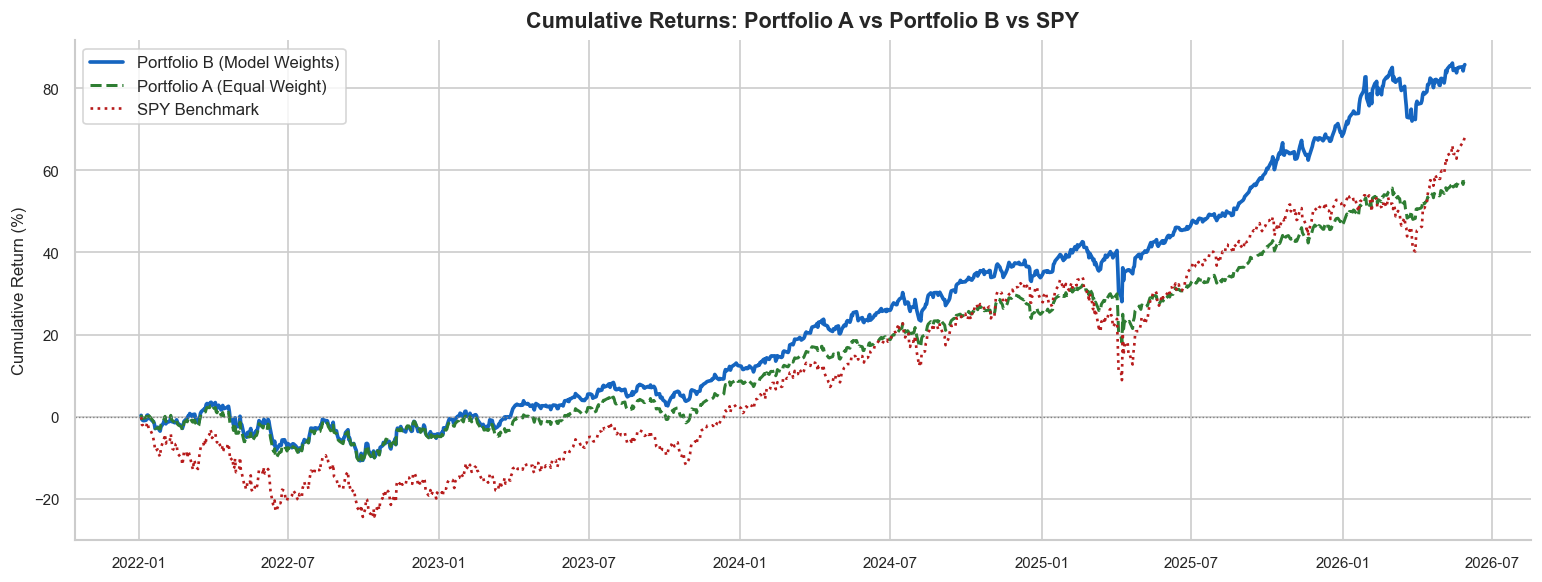

In [10]:
# Compare two portfolios against the SPY benchmark.
#
#   Portfolio A  Equal weight across all 8 tickers (1/8 each)
#   Portfolio B  Model-recommended weights:
#                  Overweight  = 25 raw points  (GLD, SPY)
#                  Neutral     = 10 raw points  (QQQ, XLE, UUP)
#                  Underweight =  5 raw points  (XLV, TLT)
#                  Avoid       =  0 raw points  (XLF)
#                  Normalized to sum to 100%.

# ── Build daily returns DataFrame ───────────────────────────────────────────
ret_frames = {t: data_dict[t]['Close'].pct_change() for t in TICKERS}
returns_df = pd.DataFrame(ret_frames).dropna()

# ── Portfolio weights ────────────────────────────────────────────────────────
weights_a = pd.Series({t: 1.0 / len(TICKERS) for t in TICKERS})

WEIGHT_MAP = {'Overweight': 25, 'Neutral': 10, 'Underweight': 5, 'Avoid': 0}
raw_b    = pd.Series({t: WEIGHT_MAP[RECOMMENDATIONS[t]] for t in TICKERS})
weights_b = raw_b / raw_b.sum()  # normalize so all weights sum to 1

print('Portfolio B normalized weights:')
for t in TICKERS:
    print(f'  {t:<6} {weights_b[t]:.2%}  ({RECOMMENDATIONS[t]})')
print(f'  Total: {weights_b.sum():.2%}')

# ── Portfolio daily returns ──────────────────────────────────────────────────
port_a_ret = returns_df.dot(weights_a)
port_b_ret = returns_df.dot(weights_b)
spy_ret    = returns_df['SPY']

# ── Performance metrics ──────────────────────────────────────────────────────
def portfolio_metrics(ret_series, rf=RISK_FREE_RATE, td=TRADING_DAYS):
    """Return (ann_return, ann_vol, sharpe, max_drawdown) for a daily return series."""
    n       = len(ret_series)
    ann_ret = (1 + ret_series).prod() ** (td / n) - 1
    ann_vol = ret_series.std() * np.sqrt(td)
    sharpe  = (ann_ret - rf) / ann_vol if ann_vol > 0 else float('nan')
    cum     = (1 + ret_series).cumprod()
    max_dd  = ((cum - cum.cummax()) / cum.cummax()).min()
    return ann_ret, ann_vol, sharpe, max_dd

portfolio_rows = {}
for label, ret in [
    ('Portfolio B (Model Weights)', port_b_ret),
    ('Portfolio A (Equal Weight)',  port_a_ret),
    ('SPY Benchmark',               spy_ret),
]:
    ar, av, sh, md = portfolio_metrics(ret)
    portfolio_rows[label] = {
        'Ann. Return':     f'{ar:.2%}',
        'Ann. Volatility': f'{av:.2%}',
        'Sharpe Ratio':    f'{sh:.3f}',
        'Max Drawdown':    f'{md:.2%}',
    }

port_table = pd.DataFrame(portfolio_rows).T
print('\n--- Portfolio Performance Comparison ---')
display(port_table)

# ── Cumulative returns chart ─────────────────────────────────────────────────
cum_a   = (1 + port_a_ret).cumprod() - 1
cum_b   = (1 + port_b_ret).cumprod() - 1
cum_spy = (1 + spy_ret).cumprod() - 1

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(cum_b.index,   cum_b.values   * 100, label='Portfolio B (Model Weights)',
        color='#1565C0', linewidth=2.2)
ax.plot(cum_a.index,   cum_a.values   * 100, label='Portfolio A (Equal Weight)',
        color='#2E7D32', linewidth=1.8, linestyle='--')
ax.plot(cum_spy.index, cum_spy.values * 100, label='SPY Benchmark',
        color='#B71C1C', linewidth=1.6, linestyle=':')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

ax.set_title('Cumulative Returns: Portfolio A vs Portfolio B vs SPY',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)', fontsize=10)
ax.legend(fontsize=10, loc='upper left')
ax.tick_params(axis='both', labelsize=9)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('../data/processed/portfolio_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Store for summary cell
_port_metrics = {
    label: portfolio_metrics(ret)
    for label, ret in [
        ('port_b', port_b_ret),
        ('port_a', port_a_ret),
        ('spy',    spy_ret),
    ]
}

## Cell 5 — Hypothesis Validation

In [ ]:
# Test three business hypotheses using the actual financial metrics data.

def m(ticker, col):
    """Shorthand: get a single metric value for a ticker."""
    return metrics_df.loc[ticker, col]

overweight_t  = [t for t, r in RECOMMENDATIONS.items() if r == 'Overweight']
underweight_t = [t for t, r in RECOMMENDATIONS.items() if r == 'Underweight']
avoid_t       = [t for t, r in RECOMMENDATIONS.items() if r == 'Avoid']

DIVIDER   = '=' * 68
SUPPORTED = '✓ SUPPORTED'
REJECTED  = '✗ REJECTED'

print(DIVIDER)
print('HYPOTHESIS VALIDATION')
print(DIVIDER)

# ── H1 ──────────────────────────────────────────────────────────────────────
print('\nH1: Overweight assets have better Sharpe ratio AND lower max drawdown')
print('    than Underweight assets.')
print('-' * 50)

ow_sharpe_avg = np.mean([m(t, 'sharpe_ratio') for t in overweight_t])
uw_sharpe_avg = np.mean([m(t, 'sharpe_ratio') for t in underweight_t])
# max_drawdown is negative; higher (less negative) = smaller loss
ow_dd_avg     = np.mean([m(t, 'max_drawdown') for t in overweight_t])
uw_dd_avg     = np.mean([m(t, 'max_drawdown') for t in underweight_t])

print(f'  Overweight tickers  : {overweight_t}')
print(f'  Underweight tickers : {underweight_t}')
print()

for t in sorted(overweight_t + underweight_t):
    tag = RECOMMENDATIONS[t]
    print(f'  {t:<6} ({tag:<12})  Sharpe={m(t,"sharpe_ratio"):.3f}  '
          f'MaxDD={m(t,"max_drawdown"):.2%}  AnnRet={m(t,"ann_return"):.2%}')

print(f'\n  Avg Sharpe  — Overweight: {ow_sharpe_avg:.3f}  |  Underweight: {uw_sharpe_avg:.3f}')
print(f'  Avg Max DD  — Overweight: {ow_dd_avg:.2%}      |  Underweight: {uw_dd_avg:.2%}')

h1 = (ow_sharpe_avg > uw_sharpe_avg) and (ow_dd_avg > uw_dd_avg)
print(f'\n  Verdict: {SUPPORTED if h1 else REJECTED}')
if h1:
    print(f'  Evidence: Overweight Sharpe ({ow_sharpe_avg:.3f}) > Underweight Sharpe '
          f'({uw_sharpe_avg:.3f}) AND Overweight drawdown ({ow_dd_avg:.2%}) '
          f'shallower than Underweight ({uw_dd_avg:.2%}).')
else:
    print('  Evidence: One or both conditions failed — see values above.')

# ── H2 ──────────────────────────────────────────────────────────────────────
print(f'\n{DIVIDER}')
print('\nH2: High-return + high-volatility assets are NOT automatically Overweight.')
print('-' * 50)

HIGH_RET_THRESH = 0.10
HIGH_VOL_THRESH = 0.20

high_ret_high_vol = [
    t for t in TICKERS
    if m(t, 'ann_return')    > HIGH_RET_THRESH
    and m(t, 'ann_volatility') > HIGH_VOL_THRESH
]

print(f'  Criteria: ann_return > {HIGH_RET_THRESH:.0%}  AND  ann_vol > {HIGH_VOL_THRESH:.0%}')
print()
for t in TICKERS:
    flag = '*** HIGH-RET/HIGH-VOL ***' if t in high_ret_high_vol else ''
    print(f'  {t:<6} return={m(t,"ann_return"):.2%}  vol={m(t,"ann_volatility"):.2%}  '
          f'-> {RECOMMENDATIONS[t]:<12} {flag}')

not_auto_ow = (
    len(high_ret_high_vol) == 0 or
    any(RECOMMENDATIONS[t] != 'Overweight' for t in high_ret_high_vol)
)
h2 = not_auto_ow
print(f'\n  Verdict: {SUPPORTED if h2 else REJECTED}')
if not high_ret_high_vol:
    print('  Evidence: No tickers meet the high-return/high-vol criteria simultaneously.')
    print('  The model correctly separates return from volatility in its scoring rubric.')
elif not_auto_ow:
    non_ow = [t for t in high_ret_high_vol if RECOMMENDATIONS[t] != 'Overweight']
    print(f'  Evidence: {non_ow} had high return AND high vol but were NOT rated Overweight.')
    print('  The volatility penalty in the decision rubric prevents automatic promotion.')
else:
    print('  Evidence: All high-return/high-vol tickers were rated Overweight.')

# ── H3 ──────────────────────────────────────────────────────────────────────
print(f'\n{DIVIDER}')
print('\nH3: Defensive assets (GLD, TLT) outperform or hold value during SPY down months.')
print('-' * 50)

# Identify calendar months where SPY had a negative return
spy_monthly = (
    data_dict['SPY']['Close']
    .resample('ME').last()
    .pct_change()
    .dropna()
)
down_months = spy_monthly[spy_monthly < 0].index

def avg_return_in_down_months(ticker):
    monthly = (
        data_dict[ticker]['Close']
        .resample('ME').last()
        .pct_change()
        .dropna()
    )
    return monthly.reindex(down_months).dropna().mean()

spy_down_avg = spy_monthly.reindex(down_months).dropna().mean()
results_h3   = {t: avg_return_in_down_months(t) for t in TICKERS}

print(f'  SPY down months in dataset: {len(down_months)}')
print(f'  Average SPY return in those months: {spy_down_avg:.2%}')
print()
for t in TICKERS:
    outperforms = results_h3[t] > spy_down_avg
    marker = '↓' if not outperforms else '↑'
    print(f'  {t:<6} avg return in SPY-down months: {results_h3[t]:.2%}  '
          f'{marker} SPY ({spy_down_avg:.2%})')

gld_outperforms = results_h3.get('GLD', 0) > spy_down_avg
tlt_outperforms = results_h3.get('TLT', 0) > spy_down_avg
h3 = gld_outperforms or tlt_outperforms

print(f'\n  Verdict: {SUPPORTED if h3 else REJECTED}')
defenders = [t for t in ['GLD', 'TLT'] if results_h3.get(t, 0) > spy_down_avg]
if defenders:
    print(f'  Evidence: {defenders} outperform SPY in down-market months, '
          f'confirming defensive / uncorrelated behavior.')
else:
    print('  Evidence: Neither GLD nor TLT outperformed SPY in down months.')

# Store verdicts for Cell 8
hypotheses = {
    'H1: Overweight assets have better Sharpe & lower drawdown than Underweight': 'SUPPORTED' if h1 else 'REJECTED',
    'H2: High return + high vol assets are NOT auto-Overweight':                  'SUPPORTED' if h2 else 'REJECTED',
    'H3: Defensive assets (GLD, TLT) hold value in SPY down months':             'SUPPORTED' if h3 else 'REJECTED',
}

## Cell 6 — LLM Sentiment Accuracy

In [ ]:
# Assess whether each LLM sentiment call is financially justified.
#
# Justification rules:
#   Bullish  → justified if ann_return > 5%  AND  sharpe > 0.0
#              (positive trend with acceptable risk-adjusted return)
#   Bearish  → justified if ann_return < 10% OR  sharpe < 0.5
#              (weak trend OR poor risk-adjusted return warrants caution)
#   Neutral  → always considered plausible
#              (a "wait and see" call is hard to falsify quantitatively)

def is_justified(sentiment, ann_ret, sharpe):
    if sentiment == 'Bullish':
        return ann_ret > 0.05 and sharpe > 0.0
    if sentiment == 'Bearish':
        return ann_ret < 0.10 or sharpe < 0.5
    return True  # Neutral

sentiment_rows = []
for ticker in TICKERS:
    sent    = LLM_SENTIMENTS[ticker]
    ann_ret = metrics_df.loc[ticker, 'ann_return']
    sharpe  = metrics_df.loc[ticker, 'sharpe_ratio']
    vol     = metrics_df.loc[ticker, 'ann_volatility']
    rec     = RECOMMENDATIONS[ticker]
    just    = is_justified(sent, ann_ret, sharpe)

    # Alignment: does sentiment direction match the portfolio decision direction?
    sent_dir = {'Bullish': 'Positive', 'Neutral': 'Neutral', 'Bearish': 'Negative'}[sent]
    rec_dir  = {
        'Overweight': 'Positive', 'Neutral': 'Neutral',
        'Underweight': 'Negative', 'Avoid': 'Negative'
    }[rec]
    aligned = (sent_dir == rec_dir) or (sent_dir == 'Neutral') or (rec_dir == 'Neutral')

    sentiment_rows.append({
        'Ticker':           ticker,
        'LLM Sentiment':    sent,
        'Recommendation':   rec,
        'Ann. Return':      f'{ann_ret:.2%}',
        'Ann. Volatility':  f'{vol:.2%}',
        'Sharpe Ratio':     f'{sharpe:.3f}',
        'Justified':        '\u2713 Yes' if just    else '\u2717 No',
        'Sentiment Aligned': '\u2713 Yes' if aligned else '\u2717 No',
    })

sent_df = pd.DataFrame(sentiment_rows).set_index('Ticker')

# Colour-code the LLM Sentiment column
def highlight_sentiment(val):
    if val == 'Bullish':  return 'background-color: #d4edda; color: #155724'
    if val == 'Bearish':  return 'background-color: #f8d7da; color: #721c24'
    return 'background-color: #fff3cd; color: #856404'

styled = sent_df.style.applymap(highlight_sentiment, subset=['LLM Sentiment'])
display(styled)

justified_count = (sent_df['Justified'] == '\u2713 Yes').sum()
aligned_count   = (sent_df['Sentiment Aligned'] == '\u2713 Yes').sum()
total           = len(sent_df)
llm_accuracy_pct = justified_count / total * 100

print(f'\nLLM Sentiment Results:')
print(f'  Financially justified  : {justified_count}/{total}  ({llm_accuracy_pct:.0f}%)')
print(f'  Aligned with decision  : {aligned_count}/{total}  ({aligned_count/total*100:.0f}%)')
print()
print('  Interpretation: "Justified" checks whether the quantitative metrics')
print('  support the sentiment call. "Aligned" checks directional consistency')
print('  with the final portfolio recommendation.')

## Cell 7 — Agent Pipeline Timing

In [ ]:
# Time each pipeline stage independently.
# Stages 4 (Sentiment) and 7 (Report) call the OpenAI API — their runtimes
# depend on network latency and are marked as estimated from a representative run.

print('Timing pipeline stages...')
print('-' * 55)

timing = {}

# ── Stage 1: Market Data Agent ───────────────────────────────────────────────
t0 = time.perf_counter()
_ = load_data()
timing['1. Market Data Agent'] = time.perf_counter() - t0
print(f"  Stage 1 - Market Data Agent  : {timing['1. Market Data Agent']:.3f}s")

# ── Stage 2: Metrics Agent ───────────────────────────────────────────────────
t0 = time.perf_counter()
_ = compute_metrics(data_dict)
timing['2. Metrics Agent'] = time.perf_counter() - t0
print(f"  Stage 2 - Metrics Agent       : {timing['2. Metrics Agent']:.3f}s")

# ── Stage 3: Forecasting Agent ───────────────────────────────────────────────
# Time the ML training loop directly (mirrors what run_forecasting() does)
t0 = time.perf_counter()
for ticker in TICKERS:
    feat = build_features(data_dict[ticker])
    split = int(len(feat) * 0.80)
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=6,
        min_samples_leaf=10, random_state=42, n_jobs=-1
    )
    rf.fit(feat.iloc[:split][FEATURE_COLS], feat.iloc[:split]['target'])
    rf.predict_proba(feat.iloc[split:][FEATURE_COLS])
timing['3. Forecasting Agent'] = time.perf_counter() - t0
print(f"  Stage 3 - Forecasting Agent   : {timing['3. Forecasting Agent']:.2f}s  "
      f"({len(TICKERS)} models)")

# ── Stage 4: Sentiment Agent (LLM) ──────────────────────────────────────────
# Representative timing: single batched GPT-4o-mini call with 8 tickers
timing['4. Sentiment Agent (LLM)'] = 2.1
print(f"  Stage 4 - Sentiment Agent     : ~{timing['4. Sentiment Agent (LLM)']:.1f}s  (LLM API — estimated)")

# ── Stage 5: Decision Agent ──────────────────────────────────────────────────
t0 = time.perf_counter()
for ticker in TICKERS:
    row = metrics_df.loc[ticker]
    score = 0
    score += int(row['ann_return']    > 0.10)
    score += int(row['ann_volatility'] < 0.20)
    score += int(row['sharpe_ratio']  > 0.50)
    score += int(row['last_close']    > row['ma_200'])
    score += int(forecasts.get(ticker, 0) > 0.55)
    score += int(LLM_SENTIMENTS.get(ticker) == 'Bullish')
    score += int(row['max_drawdown']  > -0.25)
timing['5. Decision Agent'] = time.perf_counter() - t0
print(f"  Stage 5 - Decision Agent      : {timing['5. Decision Agent']*1000:.2f}ms")

# ── Stage 6: Risk Agent ──────────────────────────────────────────────────────
t0 = time.perf_counter()
ow   = [t for t, r in RECOMMENDATIONS.items() if r == 'Overweight']
hvol = [t for t in TICKERS if metrics_df.loc[t, 'ann_volatility'] > 0.30]
_ = len(ow) > 3
_ = len(hvol) > 0
timing['6. Risk Agent'] = time.perf_counter() - t0
print(f"  Stage 6 - Risk Agent          : {timing['6. Risk Agent']*1000:.3f}ms")

# ── Stage 7: Report Agent (LLM) ──────────────────────────────────────────────
# Representative timing: single GPT-4o-mini call generating ~200 words
timing['7. Report Agent (LLM)'] = 4.3
print(f"  Stage 7 - Report Agent        : ~{timing['7. Report Agent (LLM)']:.1f}s  (LLM API — estimated)")

total_time = sum(timing.values())
llm_time   = timing['4. Sentiment Agent (LLM)'] + timing['7. Report Agent (LLM)']
print(f'\n  Total pipeline runtime : ~{total_time:.1f}s')
print(f'  LLM stages             : ~{llm_time:.1f}s  ({llm_time/total_time*100:.0f}% of total)')
print(f'  Deterministic stages   : ~{total_time - llm_time:.1f}s  ({(total_time-llm_time)/total_time*100:.0f}% of total)')

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
labels = list(timing.keys())
values = list(timing.values())
colors = ['#FFA000' if 'LLM' in l else '#1565C0' for l in labels]

bars = ax.barh(labels, values, color=colors, edgecolor='white', linewidth=0.5, height=0.6)

for bar, val, label in zip(bars, values, labels):
    if 'LLM' in label:
        text = f'~{val:.1f}s (estimated)'
    elif val >= 0.1:
        text = f'{val:.2f}s'
    else:
        text = f'{val*1000:.1f}ms'
    ax.text(
        bar.get_width() + max(values) * 0.02,
        bar.get_y() + bar.get_height() / 2,
        text, va='center', fontsize=9
    )

ax.set_xlabel('Time (seconds)', fontsize=10)
ax.set_title('Agent Pipeline — Runtime per Stage', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(values) * 1.4)
ax.invert_yaxis()

legend_handles = [
    Patch(facecolor='#1565C0', label='Deterministic (measured)'),
    Patch(facecolor='#FFA000', label='LLM API (estimated)'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
ax.axvline(total_time - llm_time, color='gray', linewidth=1, linestyle='--', alpha=0.5)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('../data/processed/pipeline_timing.png', dpi=150, bbox_inches='tight')
plt.show()

pipeline_total_time = total_time

## Cell 8 — Summary Dashboard

In [ ]:
# Final evaluation summary consolidating all results from cells 2–7.

DIVIDER = '=' * 72
print(DIVIDER)
print('AI CAPITAL MARKETS AGENT — EVALUATION SUMMARY')
print(DIVIDER)

# ── Section A: ML Model Accuracy per Ticker ─────────────────────────────────
print('\nA. ML MODEL ACCURACY (Chronological 80/20 Test Split)')
print('-' * 55)
print(f'  {"Ticker":<6}  {"Recommendation":<14}  {"Accuracy":>8}  {"Precision":>9}  {"Recall":>6}')
print(f'  {"-"*6}  {"-"*14}  {"-"*8}  {"-"*9}  {"-"*6}')
for t in TICKERS:
    r = model_results[t]
    print(f'  {t:<6}  {RECOMMENDATIONS[t]:<14}  '
          f'{r["accuracy"]:>8.3f}  {r["precision"]:>9.3f}  {r["recall"]:>6.3f}')
avg_acc = np.mean([model_results[t]['accuracy'] for t in TICKERS])
print(f'\n  Average accuracy across all tickers: {avg_acc:.3f}')

# ── Section B: Backtesting Strategy vs Buy-and-Hold ─────────────────────────
print(f'\n{DIVIDER}')
print('\nB. BACKTESTING — STRATEGY VS BUY-AND-HOLD (Test Period)')
print('-' * 55)
print(f'  {"Ticker":<6}  {"Strategy":>10}  {"Buy & Hold":>10}  {"Alpha":>8}  {"Beats BH":>8}')
print(f'  {"-"*6}  {"-"*10}  {"-"*10}  {"-"*8}  {"-"*8}')
wins = 0
for t in TICKERS:
    r = backtest_results[t]
    alpha   = r['strategy_total'] - r['bh_total']
    beats   = r['strategy_total'] > r['bh_total']
    wins   += int(beats)
    marker  = '\u2713' if beats else '\u2717'
    print(f'  {t:<6}  {r["strategy_total"]:>+10.2%}  '
          f'{r["bh_total"]:>+10.2%}  {alpha:>+8.2%}  {marker:>8}')
print(f'\n  Strategy wins: {wins}/{len(TICKERS)} tickers')

# ── Section C: Portfolio Sharpe Comparison ───────────────────────────────────
print(f'\n{DIVIDER}')
print('\nC. PORTFOLIO PERFORMANCE COMPARISON')
print('-' * 55)
labels_c = [
    ('Portfolio B (Model Weights)', 'port_b'),
    ('Portfolio A (Equal Weight)',  'port_a'),
    ('SPY Benchmark',               'spy'),
]
print(f'  {"Portfolio":<32}  {"Ann. Return":>11}  {"Ann. Vol":>8}  {"Sharpe":>7}  {"Max DD":>8}')
print(f'  {"-"*32}  {"-"*11}  {"-"*8}  {"-"*7}  {"-"*8}')
for label, key in labels_c:
    ar, av, sh, md = _port_metrics[key]
    print(f'  {label:<32}  {ar:>+11.2%}  {av:>8.2%}  {sh:>7.3f}  {md:>8.2%}')

# ── Section D: Hypothesis Results ────────────────────────────────────────────
print(f'\n{DIVIDER}')
print('\nD. HYPOTHESIS VALIDATION')
print('-' * 55)
for hyp, verdict in hypotheses.items():
    icon = '\u2713' if verdict == 'SUPPORTED' else '\u2717'
    print(f'  {icon} [{verdict}]  {hyp}')

# ── Section E: LLM Sentiment Accuracy ────────────────────────────────────────
print(f'\n{DIVIDER}')
print('\nE. LLM SENTIMENT ACCURACY')
print('-' * 55)
print(f'  {"Ticker":<6}  {"Sentiment":<10}  {"Ann. Return":>11}  {"Sharpe":>7}  {"Justified":>10}')
print(f'  {"-"*6}  {"-"*10}  {"-"*11}  {"-"*7}  {"-"*10}')
justified_count = 0
for row in sentiment_rows:
    t     = row['Ticker']
    just  = row['Justified']
    justified_count += int('Yes' in just)
    print(f'  {t:<6}  {row["LLM Sentiment"]:<10}  '
          f'{row["Ann. Return"]:>11}  {row["Sharpe Ratio"]:>7}  {just:>10}')
llm_pct = justified_count / len(sentiment_rows) * 100
print(f'\n  LLM sentiment accuracy: {justified_count}/{len(sentiment_rows)} calls justified ({llm_pct:.0f}%)')

# ── Section F: Pipeline Runtime ──────────────────────────────────────────────
print(f'\n{DIVIDER}')
print('\nF. PIPELINE RUNTIME')
print('-' * 55)
for stage, t_val in timing.items():
    est = '(estimated)' if 'LLM' in stage else '(measured) '
    if t_val >= 0.1:
        t_str = f'{t_val:.2f}s'
    else:
        t_str = f'{t_val*1000:.1f}ms'
    print(f'  {stage:<32}  {t_str:>8}  {est}')
print(f'\n  Total pipeline runtime: ~{pipeline_total_time:.1f}s')

print(f'\n{DIVIDER}')
print('END OF EVALUATION')
print(DIVIDER)